В домашней работе вам необходимо с помощью **FastAPI** реализовать **REST API**:

1. На 3 балла. Ваш REST API - это список покупок и содержит поля: название товара, группа товара (например, электроника или продовольствие), цена, единица измерения, количество. Также необходимо реализовать метод, который возвращает список - расходы по каждой группе товаров и сумму всех покупок.

  Также необходимо с помощью библиотеки `requests` продемонстрировать запросами к REST API, как работает ваш веб-сервис. Это задание можно сравнить с "покрытием тестами" вашего API. Нечто похожее делают тестировщики в ИТ-компаниях. Вам необходимо покрыть запросами все методы, которые вы реализуете на веб-сервере.

2. На 4 балла. Вам необходимо сделать красивую документацию для вашего REST API с подробным описанием. Для этого вам придется обратиться к документации:
  * https://fastapi.tiangolo.com/ru/tutorial/metadata/  
  * https://fastapi.tiangolo.com/ru/tutorial/path-operation-configuration/#response-description
3. На 5 баллов. Творческое задание. REST API можно использовать для взаимодействия с вашей моделью нейронной сети. Вы уже знаете, что можно обучить модель, а лучший результат выгрузить для дальнейшего использования. Для получения 5 баллов необходимо обучить свою модель, загрузить ее в Colab. Задача может быть любой: регрессии, классификации, входными данными могут быть картинки или текстовые данные. С помощью REST API обеспечьте взаимодействие с моделью. Это полностью творческое задание!



In [ ]:
pip install fastapi uvicorn requests pydantic tensorflow scikit-learn joblib matplotlib pandas

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
X: (150, 4)
Классы: ['setosa', 'versicolor', 'virginica']
Эпох: 26
Лучшая val_accuracy: 100.00%
TEST accuracy: 93.33%

              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9000    0.9000    0.9000        10
   virginica     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30



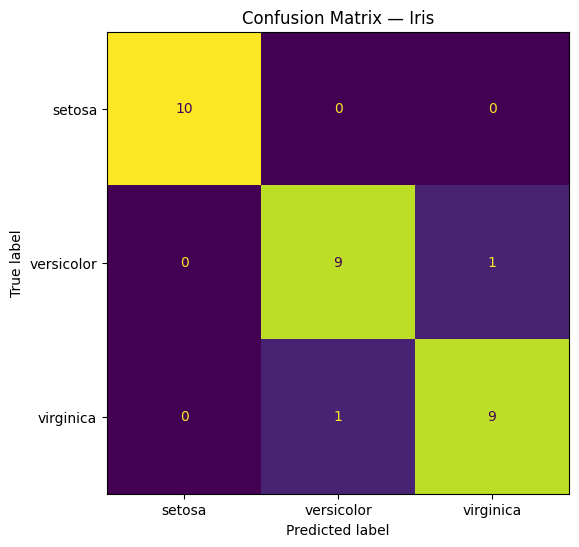

Модель: /content/iris_classifier.keras
Scaler: /content/iris_scaler.joblib
Повторная загрузка выполнена
API: http://127.0.0.1:8000
Swagger: http://127.0.0.1:8000/docs
ReDoc: http://127.0.0.1:8000/redoc

GET /health
GET http://127.0.0.1:8000/health
STATUS: 200
JSON: {'status': 'ok', 'model_loaded': True}

POST /items
POST http://127.0.0.1:8000/items
STATUS: 201
JSON: {'name': 'Ноутбук', 'group': 'Электроника', 'price': 85000.0, 'unit': 'шт.', 'quantity': 1.0, 'id': 1, 'total_cost': 85000.0}

POST /items
POST http://127.0.0.1:8000/items
STATUS: 201
JSON: {'name': 'Наушники', 'group': 'Электроника', 'price': 7500.0, 'unit': 'шт.', 'quantity': 2.0, 'id': 2, 'total_cost': 15000.0}

POST /items
POST http://127.0.0.1:8000/items
STATUS: 201
JSON: {'name': 'Молоко', 'group': 'Продовольствие', 'price': 95.0, 'unit': 'л', 'quantity': 3.0, 'id': 3, 'total_cost': 285.0}

POST /items
POST http://127.0.0.1:8000/items
STATUS: 201
JSON: {'name': 'Хлеб', 'group': 'Продовольствие', 'price': 70.0, 'unit':

In [ ]:
# Тут FastAPI + мини-нейросеть
# Установка: pip install fastapi uvicorn requests pydantic tensorflow scikit-learn joblib matplotlib pandas

# Импорты
import os
import random
import threading
import time
from pathlib import Path
from typing import Optional

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import tensorflow as tf
import uvicorn

from fastapi import FastAPI, HTTPException, status
from pydantic import BaseModel, Field, ConfigDict

from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# ===
iris = load_iris()

X = iris.data.astype(np.float32)
y = iris.target.astype(np.int32)

CLASS_NAMES = [str(x) for x in iris.target_names]

print("X:", X.shape)
print("Классы:", CLASS_NAMES)

# ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

# Нормализатор обучаем только на train.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

# ===
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,), name="iris_features"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax", name="species"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=20,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

print("Эпох:", len(history.history["loss"]))
print("Лучшая val_accuracy:", f"{max(history.history['val_accuracy']) * 100:.2f}%")

# ===
y_prob = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("TEST accuracy:", f"{accuracy_score(y_test, y_pred) * 100:.2f}%")
print()
print(classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
).plot(ax=ax, colorbar=False)

plt.title("Confusion Matrix — Iris")
plt.show()

# ===
MODEL_PATH = Path("/content/iris_classifier.keras")
SCALER_PATH = Path("/content/iris_scaler.joblib")

model.save(MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

loaded_model = tf.keras.models.load_model(MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)

print("Модель:", MODEL_PATH)
print("Scaler:", SCALER_PATH)
print("Повторная загрузка выполнена")

# ===
class ShoppingItemCreate(BaseModel):
    model_config = ConfigDict(
        json_schema_extra={
            "examples": [{
                "name": "Ноутбук",
                "group": "Электроника",
                "price": 85000,
                "unit": "шт.",
                "quantity": 1
            }]
        }
    )

    name: str = Field(..., min_length=1, max_length=100, description="Название товара")
    group: str = Field(..., min_length=1, max_length=100, description="Группа товара")
    price: float = Field(..., gt=0, description="Цена одной единицы")
    unit: str = Field(..., min_length=1, max_length=30, description="Единица измерения")
    quantity: float = Field(..., gt=0, description="Количество")


class ShoppingItemUpdate(BaseModel):
    name: Optional[str] = Field(None, min_length=1, max_length=100)
    group: Optional[str] = Field(None, min_length=1, max_length=100)
    price: Optional[float] = Field(None, gt=0)
    unit: Optional[str] = Field(None, min_length=1, max_length=30)
    quantity: Optional[float] = Field(None, gt=0)


class ShoppingItemResponse(ShoppingItemCreate):
    id: int
    total_cost: float


class ExpensesResponse(BaseModel):
    by_group: dict[str, float]
    total: float


class DeleteResponse(BaseModel):
    message: str
    deleted_id: int


class HealthResponse(BaseModel):
    status: str
    model_loaded: bool


class IrisRequest(BaseModel):
    model_config = ConfigDict(
        json_schema_extra={
            "examples": [{
                "sepal_length": 5.1,
                "sepal_width": 3.5,
                "petal_length": 1.4,
                "petal_width": 0.2
            }]
        }
    )

    sepal_length: float = Field(..., gt=0, description="Длина чашелистика, см")
    sepal_width: float = Field(..., gt=0, description="Ширина чашелистика, см")
    petal_length: float = Field(..., gt=0, description="Длина лепестка, см")
    petal_width: float = Field(..., gt=0, description="Ширина лепестка, см")


class IrisPredictionResponse(BaseModel):
    predicted_class: str
    class_id: int
    confidence: float
    probabilities: dict[str, float]

# ============================================================================
api_description = """
# Магазин и Нейросеть с API

## Покупки
CRUD-операции со списком покупок и расчёт расходов.

## Нейросеть
`POST /model/predict` передаёт данные цветка модели TensorFlow/Keras,
которая была сохранена и затем загружена обратно из `.keras`.

## Документация
- Swagger UI: `/docs`
- ReDoc: `/redoc`
"""

tags_metadata = [
    {"name": "Service", "description": "Состояние API и модели."},
    {"name": "Shopping list", "description": "CRUD списка покупок."},
    {"name": "Expenses", "description": "Расходы по группам и общая сумма."},
    {"name": "Neural network", "description": "REST-интерфейс к нейросети."},
]

app = FastAPI(
    title="Магазин и нейросеть с REST API",
    summary="Список покупок и интерфейс к нейронной сети",
    description=api_description,
    version="1.0.0",
    contact={"name": "Student REST API project"},
    license_info={"name": "MIT", "identifier": "MIT"},
    openapi_tags=tags_metadata,
)

# Учебное хранилище в памяти.
shopping_items: dict[int, dict] = {}
next_item_id = 1


def make_item_response(item_id: int, item_data: dict) -> ShoppingItemResponse:
    return ShoppingItemResponse(
        id=item_id,
        total_cost=round(float(item_data["price"] * item_data["quantity"]), 2),
        **item_data,
    )

# ===
@app.get(
    "/health",
    tags=["Service"],
    response_model=HealthResponse,
    summary="Проверить состояние API",
    description="Проверяет веб-сервис и факт загрузки нейросети.",
    response_description="Состояние API и модели",
)
def health_check():
    return HealthResponse(
        status="ok",
        model_loaded=(loaded_model is not None and loaded_scaler is not None),
    )

# ===
@app.post(
    "/items",
    tags=["Shopping list"],
    response_model=ShoppingItemResponse,
    status_code=status.HTTP_201_CREATED,
    summary="Добавить товар",
    description="Создаёт новую позицию и автоматически рассчитывает `total_cost`.",
    response_description="Созданный товар",
)
def create_item(item: ShoppingItemCreate):
    global next_item_id

    item_id = next_item_id
    next_item_id += 1

    shopping_items[item_id] = item.model_dump()

    return make_item_response(item_id, shopping_items[item_id])

# ===
@app.get(
    "/items",
    tags=["Shopping list"],
    response_model=list[ShoppingItemResponse],
    summary="Получить весь список",
    description="Возвращает все позиции списка покупок.",
    response_description="Полный список покупок",
)
def get_items():
    return [
        make_item_response(item_id, item)
        for item_id, item in shopping_items.items()
    ]

# ===
@app.get(
    "/items/{item_id}",
    tags=["Shopping list"],
    response_model=ShoppingItemResponse,
    summary="Получить товар по ID",
    description="Возвращает одну позицию списка.",
    response_description="Найденный товар",
    responses={404: {"description": "Товар не найден"}},
)
def get_item(item_id: int):
    if item_id not in shopping_items:
        raise HTTPException(status_code=404, detail="Товар не найден")

    return make_item_response(item_id, shopping_items[item_id])

# ===
@app.put(
    "/items/{item_id}",
    tags=["Shopping list"],
    response_model=ShoppingItemResponse,
    summary="Полностью заменить товар",
    description="PUT требует передать все поля позиции.",
    response_description="Обновлённый товар",
    responses={404: {"description": "Товар не найден"}},
)
def replace_item(item_id: int, item: ShoppingItemCreate):
    if item_id not in shopping_items:
        raise HTTPException(status_code=404, detail="Товар не найден")

    shopping_items[item_id] = item.model_dump()

    return make_item_response(item_id, shopping_items[item_id])

# ===
@app.patch(
    "/items/{item_id}",
    tags=["Shopping list"],
    response_model=ShoppingItemResponse,
    summary="Частично изменить товар",
    description="PATCH изменяет только переданные поля.",
    response_description="Товар после изменения",
    responses={404: {"description": "Товар не найден"}},
)
def update_item(item_id: int, item: ShoppingItemUpdate):
    if item_id not in shopping_items:
        raise HTTPException(status_code=404, detail="Товар не найден")

    changes = item.model_dump(exclude_unset=True)
    shopping_items[item_id].update(changes)

    return make_item_response(item_id, shopping_items[item_id])

# ===
@app.delete(
    "/items/{item_id}",
    tags=["Shopping list"],
    response_model=DeleteResponse,
    summary="Удалить товар",
    description="Удаляет позицию по ID.",
    response_description="Подтверждение удаления",
    responses={404: {"description": "Товар не найден"}},
)
def delete_item(item_id: int):
    if item_id not in shopping_items:
        raise HTTPException(status_code=404, detail="Товар не найден")

    del shopping_items[item_id]

    return DeleteResponse(
        message="Товар удалён",
        deleted_id=item_id,
    )

# ===
@app.get(
    "/expenses",
    tags=["Expenses"],
    response_model=ExpensesResponse,
    summary="Рассчитать расходы",
    description="Считает `price × quantity` по группам и общую сумму.",
    response_description="Расходы по группам и общая сумма",
)
def get_expenses():
    by_group: dict[str, float] = {}

    for item in shopping_items.values():
        cost = item["price"] * item["quantity"]
        group = item["group"]
        by_group[group] = by_group.get(group, 0.0) + cost

    by_group = {
        group: round(float(value), 2)
        for group, value in by_group.items()
    }

    return ExpensesResponse(
        by_group=by_group,
        total=round(float(sum(by_group.values())), 2),
    )

# ===
@app.post(
    "/model/predict",
    tags=["Neural network"],
    response_model=IrisPredictionResponse,
    summary="Классифицировать Iris",
    description="Передаёт четыре признака загруженной Keras-модели.",
    response_description="Класс и вероятности нейросети",
)
def predict_iris(request: IrisRequest):
    features = np.array([[
        request.sepal_length,
        request.sepal_width,
        request.petal_length,
        request.petal_width,
    ]], dtype=np.float32)

    scaled = loaded_scaler.transform(features).astype(np.float32)
    probabilities = loaded_model.predict(scaled, verbose=0)[0]

    class_id = int(np.argmax(probabilities))

    return IrisPredictionResponse(
        predicted_class=CLASS_NAMES[class_id],
        class_id=class_id,
        confidence=round(float(probabilities[class_id]), 6),
        probabilities={
            CLASS_NAMES[i]: round(float(p), 6)
            for i, p in enumerate(probabilities)
        },
    )

# ===
HOST = "127.0.0.1"
PORT = 8000
BASE_URL = f"http://{HOST}:{PORT}"


def run_api():
    uvicorn.run(
        app,
        host=HOST,
        port=PORT,
        log_level="warning",
    )


server_is_running = False

try:
    server_is_running = (
        requests.get(f"{BASE_URL}/health", timeout=1).status_code == 200
    )
except requests.RequestException:
    pass


if not server_is_running:
    thread = threading.Thread(target=run_api, daemon=True)
    thread.start()

    for _ in range(20):
        try:
            if requests.get(f"{BASE_URL}/health", timeout=1).status_code == 200:
                server_is_running = True
                break
        except requests.RequestException:
            pass

        time.sleep(0.25)


if not server_is_running:
    raise RuntimeError("FastAPI не удалось запустить")


print("API:", BASE_URL)
print("Swagger:", f"{BASE_URL}/docs")
print("ReDoc:", f"{BASE_URL}/redoc")

# ===
def show_response(title, response):
    print("\n" + "=" * 70)
    print(title)
    print(response.request.method, response.request.url)
    print("STATUS:", response.status_code)

    try:
        print("JSON:", response.json())
    except ValueError:
        print(response.text[:300])

# ===
# GET /health
r = requests.get(f"{BASE_URL}/health")
show_response("GET /health", r)

assert r.status_code == 200
assert r.json()["model_loaded"] is True

# ===
# POST /items
test_items = [
    {"name": "Ноутбук", "group": "Электроника", "price": 85000, "unit": "шт.", "quantity": 1},
    {"name": "Наушники", "group": "Электроника", "price": 7500, "unit": "шт.", "quantity": 2},
    {"name": "Молоко", "group": "Продовольствие", "price": 95, "unit": "л", "quantity": 3},
    {"name": "Хлеб", "group": "Продовольствие", "price": 70, "unit": "шт.", "quantity": 2},
    {"name": "Шампунь", "group": "Бытовые товары", "price": 450, "unit": "шт.", "quantity": 2},
]

created_ids = []

for item in test_items:
    r = requests.post(f"{BASE_URL}/items", json=item)
    show_response("POST /items", r)

    assert r.status_code == 201
    created_ids.append(r.json()["id"])

print("Созданные ID:", created_ids)

# ===
# GET /items
r = requests.get(f"{BASE_URL}/items")
show_response("GET /items", r)

assert r.status_code == 200
assert len(r.json()) == 5

# ===
# GET /items/{id}
item_id = created_ids[0]

r = requests.get(f"{BASE_URL}/items/{item_id}")
show_response(f"GET /items/{item_id}", r)

assert r.status_code == 200
assert r.json()["name"] == "Ноутбук"

# ===
# PUT /items/{id}
item_id = created_ids[0]

replacement = {
    "name": "Игровой ноутбук",
    "group": "Электроника",
    "price": 120000,
    "unit": "шт.",
    "quantity": 1,
}

r = requests.put(
    f"{BASE_URL}/items/{item_id}",
    json=replacement,
)

show_response(f"PUT /items/{item_id}", r)

assert r.status_code == 200
assert r.json()["price"] == 120000

# ===
# PATCH /items/{id}
item_id = created_ids[1]

r = requests.patch(
    f"{BASE_URL}/items/{item_id}",
    json={"price": 7000, "quantity": 3},
)

show_response(f"PATCH /items/{item_id}", r)

assert r.status_code == 200
assert r.json()["price"] == 7000
assert r.json()["quantity"] == 3

# ===
# GET /expenses
r = requests.get(f"{BASE_URL}/expenses")
show_response("GET /expenses", r)

assert r.status_code == 200
assert "by_group" in r.json()
assert "total" in r.json()

print("\nРасходы:")
for group, amount in r.json()["by_group"].items():
    print(f"{group}: {amount:.2f}")

print(f"ВСЕГО: {r.json()['total']:.2f}")

# ===
# POST /model/predict
flowers = [
    {"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2},
    {"sepal_length": 6.0, "sepal_width": 2.9, "petal_length": 4.5, "petal_width": 1.5},
    {"sepal_length": 6.7, "sepal_width": 3.1, "petal_length": 5.6, "petal_width": 2.4},
]

for flower in flowers:
    r = requests.post(
        f"{BASE_URL}/model/predict",
        json=flower,
    )

    show_response("POST /model/predict", r)

    assert r.status_code == 200
    assert "predicted_class" in r.json()
    assert "probabilities" in r.json()

# ===
# DELETE /items/{id}
item_id = created_ids[-1]

r = requests.delete(f"{BASE_URL}/items/{item_id}")
show_response(f"DELETE /items/{item_id}", r)

assert r.status_code == 200
assert r.json()["deleted_id"] == item_id

# ===
# Проверяем список после удаления.
r = requests.get(f"{BASE_URL}/items")
show_response("GET /items после DELETE", r)

assert r.status_code == 200
assert len(r.json()) == 4

# ===
openapi_r = requests.get(f"{BASE_URL}/openapi.json")
docs_r = requests.get(f"{BASE_URL}/docs")
redoc_r = requests.get(f"{BASE_URL}/redoc")

print("OpenAPI:", openapi_r.status_code)
print("Swagger:", docs_r.status_code)
print("ReDoc:", redoc_r.status_code)

assert openapi_r.status_code == 200
assert docs_r.status_code == 200
assert redoc_r.status_code == 200

schema = openapi_r.json()

print("\nНазвание:", schema["info"]["title"])
print("Версия:", schema["info"]["version"])

print("\nEndpoints:")
for path, methods in schema["paths"].items():
    print(path, "->", list(methods.keys()))
